# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [7]:
df = pd.read_csv("BASE_SUPERMERCADO.csv", delimiter=',')

df

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
...,...,...,...,...,...,...,...
1102,"Helado bresler pote cassata 2,4l",Bresler,0,4359,5449,1090,congelados
1103,"Helado Trisabor chocolate lúcuma y manjar 2,4 L",Bresler,0,4359,5449,1090,congelados
1104,Shampoo Reconstrucción Completa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal
1105,Acondicionador Hidratación Intensa 400 ml,Dove,0,2690,3849,1159,belleza-y-cuidado-personal


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [44]:
#Seu código aqui para a médi
df.groupby('Categoria')['Preco_Normal'].mean().to_frame()

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1783.556485
comidas-preparadas,3095.043478
congelados,2108.042553
frutas,1724.473684
instantaneos-y-sopas,765.491228
lacteos,2385.219239
verduras,1343.296875


In [45]:
#Seu código aqui para a mediana
df.groupby('Categoria')['Preco_Normal'].median().to_frame()

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1569.0
comidas-preparadas,3290.0
congelados,1519.0
frutas,1195.0
instantaneos-y-sopas,439.0
lacteos,989.0
verduras,1180.0


In [51]:
# Separação automática.
media_maior=[]
media_menor=[]
df_analise = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median'])
for linha in range(len(df_analise)):
    categoria = df_analise.index[linha]
    if df_analise['mean'].iloc[linha] > df_analise['median'].iloc[linha]:
        media_maior.append(categoria)
    else:
        media_menor.append(categoria)

print('Media maior:', media_maior)
print('Media menor:', media_menor)

Media maior: ['belleza-y-cuidado-personal', 'congelados', 'frutas', 'instantaneos-y-sopas', 'lacteos', 'verduras']
Media menor: ['comidas-preparadas']


Digite aqui as categorias:

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [55]:
#Seu código aqui
df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median','std']).sort_values('std', ascending=False)

,mean,median,std
Categoria,,,
lacteos,2385.219239,989.0,3925.816164
belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719
congelados,2108.042553,1519.0,2111.539896
comidas-preparadas,3095.043478,3290.0,2019.911428
frutas,1724.473684,1195.0,1639.151114
instantaneos-y-sopas,765.491228,439.0,1170.232869
verduras,1343.296875,1180.0,1012.699625


Digite nesse campo o comportamento que você identificou.

In [ ]:
# Indentifiquei que a media e a mediana podem apresentar uma diferença alta caso estejam com um alto desvio padrão. 

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

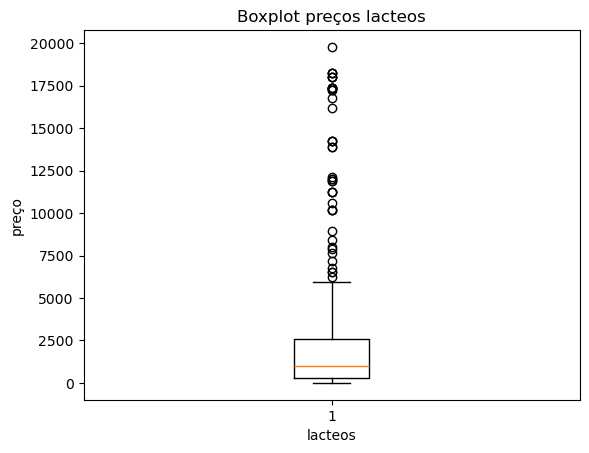

In [63]:
#Seu código aqui
lacteos = df.Preco_Normal[df.Categoria=='lacteos']
plt.boxplot(lacteos)
plt.xlabel('lacteos')
plt.ylabel('preço')
plt.title('Boxplot preços lacteos')
plt.show()

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

In [69]:
# Seu código aqui
desconto_categoria = df.groupby('Categoria')['Preco_Desconto'].mean()
desconto_categoria

Categoria
belleza-y-cuidado-personal    1051.326360
comidas-preparadas             685.434783
congelados                     888.208511
frutas                           0.000000
instantaneos-y-sopas           117.614035
lacteos                        178.796421
verduras                         0.000000
Name: Preco_Desconto, dtype: float64

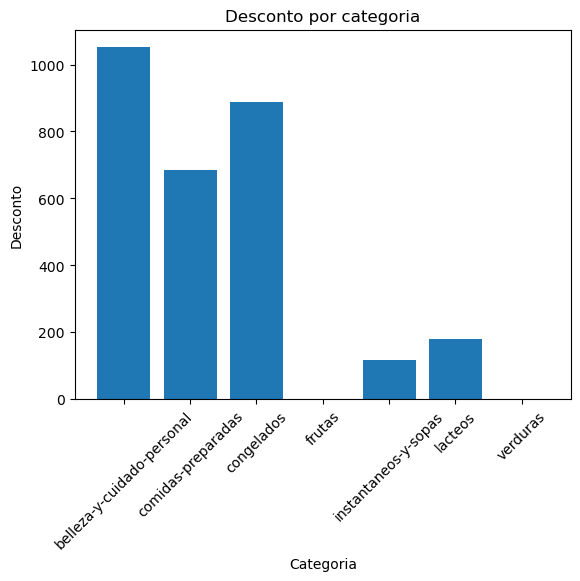

In [75]:
plt.bar(desconto_categoria.index, desconto_categoria)
plt.ylabel('Desconto')
plt.xlabel('Categoria')
plt.xticks(rotation=45)
plt.title('Desconto por categoria');

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

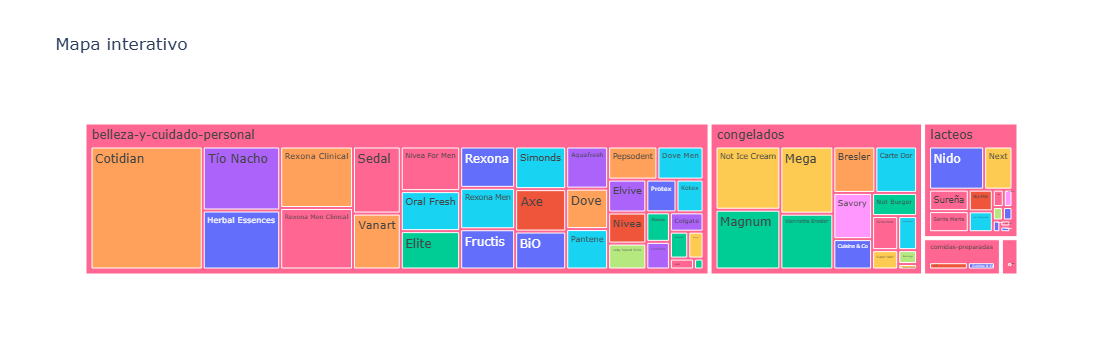

In [84]:
# Seu código aqui
df_agrupado = df.groupby(['Categoria', 'Marca'])['Preco_Desconto'].mean().reset_index()

fig = px.treemap(
    df_agrupado,
    path=['Categoria', 'Marca'],
    values='Preco_Desconto',
    title='Mapa interativo',
    color='Marca'
)
fig.show()